# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

Tecnológico de Monterrey

Prof Luis Eduardo Falcón Morales

### **Actividad de la semana: modelos basados en Árboles**


* **Nombre: Kevin Rogelio Rodriguez Magaña**

* **matrícula: A01840418**


Agrega tus comentarios y celdas de código donde se te indica.

# **PRIMERA PARTE : Métricas de Clasificación**

In [1]:
# Importamos lo necesario para la actividad:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
from sklearn.dummy import DummyClassifier

np.random.seed(17)

In [2]:
# Para esta primera parte vamos a generar datos sintéticos para un problema de
# clasificación binario utilizando "make_classification" de scikitlearn.
# Esta función es muy útil para generar datos sintéticos y usada mucho en la
# comunidad de aprendizaje automático para generar y aprender los diversos
# modelos de aprendizaje automático. Por lo que es importante que te
# familiarices con ella y algunos de sus argumentos como mostramos a continuación.

# Recuerda consultar la documentación para mayor información:
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html


# Utilizaremos los siguientes valores de los hiperparámetros de make_classification:
# - n_samples: número de muestras o registros a generar.
# - n_features: número total de características o variables de entrada X. Incluye informativas, redundantes, duplicadas.
# - n_informative: número de características informativas o independientes.
# - n_redundant: número de características redundantes.
# - weights: pesos para las clases [0,1]-->[Clase_Mayoritaria_Negativa(0), clase_minoritaria_positiva(1)].
# - class_sep: separación entre clases ( <1 más entrelazados y más complejo el problema. >1, más separados y más fácil de resolver).
# - n_classes: número de clases.
# - n_clusters_per_class: número de cúmulos por clase. Mayor a 1, más complejo.
# - flip_y: fracción de registros cuya etiqueta se cambia de manera errónea y aleatoria (ruido) para hacer más complejo el problema.
# - random_state: semilla para reproducibilidad.

X, y = make_classification(
    n_samples=10_000,          # 10,000 registros
    n_features=20,             # factores en total
    n_informative=15,          # factores informativos o variables de entrada independientes
    n_redundant=5,             # factores redundantes (dependientes). Para añadir complejidad usamos valor > 0
    weights=[0.88, 0.12],      # Desbalance de clases: Mayoritaria clase 0; minoritaria clase 1
    class_sep=1.0,             # Separación entre clases. Más grande, más separadas y problemas más sencillos.
    n_classes=2,               # Dos clases para nuestro ejercicio.
    n_clusters_per_class=1,    # Para agregar complejidad adicional considera valores > 1
    flip_y=0.01,               # Añadir algo de ruido. default 0.01
    random_state=17,           # Semilla para la repetibilidad
)

In [3]:
# Defimos los datos como un DataFrame de Pandas para su mejor manejo:
feature_names = [f'feature_{i+1}' for i in range(20)]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Total de registros generados: {len(df)}")
print(f"Distribución de clases: {df['target'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'}")
print(f"Cantidad de factores: {len(feature_names)}")

Total de registros generados: 10000
Distribución de clases: target
0    87.7%
1    12.3%
Name: proportion, dtype: object
Cantidad de factores: 20


In [4]:
pd.DataFrame(df).describe().T

,count,mean,std,min,25%,50%,75%,max
feature_1,10000.0,1.016138,2.243319,-6.429702,-0.520059,1.025274,2.535350,9.286981
feature_2,10000.0,0.785670,1.994150,-8.578184,-0.462409,0.851269,2.137617,7.937184
feature_3,10000.0,-0.757783,2.127136,-9.574402,-2.200615,-0.782594,0.630210,9.676054
feature_4,10000.0,1.733561,4.820216,-19.158886,-1.578108,1.751568,5.036626,19.051885
feature_5,10000.0,1.004263,2.309019,-6.665816,-0.540579,0.990261,2.538778,9.991830
feature_6,10000.0,-0.758315,2.682632,-11.246005,-2.561001,-0.780123,1.025289,10.297298
feature_7,10000.0,-0.448463,5.527866,-24.457356,-4.152116,-0.447135,3.285445,21.695749
feature_8,10000.0,0.974038,2.446141,-7.820102,-0.651334,0.977687,2.634129,11.292973
feature_9,10000.0,-0.769954,2.546797,-11.410437,-2.475215,-0.740625,0.947244,7.435675
feature_10,10000.0,0.739749,2.267579,-7.860020,-0.747975,0.768796,2.290440,9.363365


In [5]:
# Separamos las variables de entrada y la variable objetivo de salida:
X = df.drop('target', axis=1).values
y = df['target'].values

# Para los fines de este ejercicios solo dividimos el conjunto de datos
# en entrenamiento (80%) y validación (20%).
# Además usamos "stratify" para mantener la proporción de clases en la partición.
Xtrain, Xvalidation, ytrain, yvalidation = train_test_split(X, y, train_size=0.8, random_state=17, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {Xtrain.shape[0]} muestras")
print(f"Tamaño del conjunto de validación: {Xvalidation.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 8000 muestras
Tamaño del conjunto de validación: 2000 muestras


**Recuerda revisar la documentación de la función Dummy:**

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

In [6]:
# Obtengamos los siguientes resultados con la función Dummy:

estrategias = ['most_frequent','prior','stratified','uniform', "constant"]

print("Salidas del modelo Dummy con sus diferentes estrategias para")
print("buscar los diferentes umbrales del modelo base (baseline)")
print("según la métrica de referencia:")
print("-"*60)
print("\n")

for estrategia in estrategias:
  dummy_clf = DummyClassifier(strategy=estrategia,
                              random_state=17,
                              constant=1
                              )
  dummy_clf.fit(Xtrain, ytrain)
  y_pred = dummy_clf.predict(Xvalidation)

  # Lista para almacenar resultados
  results = []

  # "pos_label" indica la clase con respecto a la cual evaluar cada métrica.
  # Esto es útil en caso de que la clase de interés tenga un valor particular.
  acc = accuracy_score(yvalidation, y_pred)
  rec = recall_score(yvalidation, y_pred, pos_label=1)
  prec = precision_score(yvalidation, y_pred, pos_label=1)
  f1_sc = f1_score(yvalidation, y_pred, pos_label=1)

  results.append({'Accuracy': acc,
                'Recall': rec,
                'Precision': prec,
                'F1 Score': f1_sc
                })

  print(f"Estrategia: {estrategia}")
  print(f"Accuracy: {acc:.4f}")
  print(f"Recall: {rec:.4f}")
  print(f"Precision: {prec:.4f}")
  print(f"F1 Score: {f1_sc:.4f}")

  print("Matriz de Confusión:")
  cm = confusion_matrix(yvalidation, y_pred)
  print(cm)
  print("-"*30)
  print("\n")


Salidas del modelo Dummy con sus diferentes estrategias para
buscar los diferentes umbrales del modelo base (baseline)
según la métrica de referencia:
------------------------------------------------------------


Estrategia: most_frequent
Accuracy: 0.8770
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
Matriz de Confusión:
[[1754    0]
 [ 246    0]]
------------------------------


Estrategia: prior
Accuracy: 0.8770
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
Matriz de Confusión:
[[1754    0]
 [ 246    0]]
------------------------------


Estrategia: stratified
Accuracy: 0.8060
Recall: 0.1341
Precision: 0.1587
F1 Score: 0.1454
Matriz de Confusión:
[[1579  175]
 [ 213   33]]
------------------------------


Estrategia: uniform
Accuracy: 0.4820
Recall: 0.4472
Precision: 0.1089
F1 Score: 0.1752
Matriz de Confusión:
[[854 900]
 [136 110]]
------------------------------


Estrategia: constant
Accuracy: 0.1230
Recall: 1.0000
Precision: 0.1230
F1 Score: 0.2191
Matriz de Confusión:
[[

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Ejercicio - 1**


**En la salida anterior se obtuvieron dos advertencias (warnings).**

* **1a) Explica en qué consisten cada una de estas 5 estrategias. En particular, ¿cuál es la diferencia entre "prior" y "most frequent"?**

* **1b) ¿A cuáles casos de las estrategias Dummy están asociadas esas advertencias?**

* **1c) Explica qué significan esas advertencias y relaciona la explicación con los valores de las matrices de confusión correspondientes.**

* **1d) Suponiendo que vamos a utilizar estos datos para entrenar un modelo basado en árboles, ¿cuál es la recomendación en relación a si debemos o no escalar los datos numéricos de entrada?**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* **1a)** Las 5 estrategias son most frquent que predice cual es la clse mas comun. Prior que es la distribucion previa de clases. Stratified, esta predice de manera aleatoria con las proporciones de clases. Uniform, que nos predice aleatoriamente con la misma probabilidad. Constant es una clase fija definida por nosotros. La diferencia de Most frequent y prior es qwue aunque predicen la clase mayoritaria, Prior conserva la distribucion de probabilidades.

* **1b)** Estan relacionadas a las estrategias most frequent y prior ya que ambas nos predicen para clases mayoritaria pero noo para las minoritarias

* **1c)** Nos indica que laa metrica de precision no se calcula por que no hay predicciones de la clase positiva, debido que las columnas de prediccion aparecen con valores en cero.

* **1d)** No es necesario si se utilizan modelos basados en arboles, no es necesario escalar datos numericos ya que estoy relaizan divisiones mediante unas reglas por lo que no es necesario escala de variables

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

## **Ejercicio - 2**

**Sabemos que tenemos un problema de clases desbalanceadas y debiéramos utilizar otra métrica que nos ayude a medir mejor el desempeño del modelo. En particular, nos interesaría saber cuándo el modelo está subentrenado con respecto a una métrica en particular.**

**Para ello, indica cuál sería el valor del modelo base (baseline) que debiéramos utilizar, si utilizáramos como métrica la que se indica en cada inciso:**


++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++


* **2a) Accuracy:** El modelo seria most frequent ya que la la exactitud puede ser que se infle cuando es desbalanceado al predicir la clase prioritaria.

* **2b) Precision:**  El modelo seria most frequent o prior ya que ambos pueden predicir con la clae mayoritaria y pueden identificar si el modelo mejor al usar la clase positiva.

* **2c) Recall:**  El modelo seria most frequent, porque al no predecir la clse minoritaria su recall va a ser 0, con un punto minimo de comparacion

* **2d) F1-Score:**  El modelo se basa en most frequent ya que la precision y recal muy bajos o nulos, el F1 score tambien sera cercano a 0 y nos sirve como referencia minima

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

# **SEGUNDA PARTE : XGBoost**

### **En el siguiente ejercicio explorarás el efecto de algunos de los argumentos del modelo XGBoost.**

 Puedes consultar la documentación:

https://xgboost.readthedocs.io/en/latest/python/python_api.html

Usaremos la base de datos llamada breast-cancer-Wisconsin:

https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html



## **Ejercicio - 3**

### **Describe en qué consiste la base de datos breast_cancer.**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

Contiene informacion obtenida de estudios medicos sobre tumores.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

In [15]:
# Importamos las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from xgboost import plot_importance, plot_tree

In [18]:
# Cargamos el dataset de ejemplo:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)


## **Ejercicio - 4**

**De la documentación, sabemos que las etiquetas están dadas como sigue:**

* **Malignant (0)**

* **Benign (1)**

* **Distribución de clases: 212 malignos, 357 benignos.**

**Describe 3 razones a favor y 3 en contra para dejar las etiquetas como fueron registradas en esta base de datos.**

**4a) Razones a favor de dejar las etiquetas como están:**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* **4a.1) Asi no tenemos que modificar la estructura**

* **4a.2) Podemos hacer una comparacion usando las flags mostrando esto**

* **4a.3) Puede ser conveniente para el manejo y consulta**

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

**4b) Razones en contra de dejar las etiquetas como están, es decir, a favor de intercambiarlas:**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* **4b.1) Por problemas de interpretacion**

* **4b.2) Cuando asignamos valores y lo utilizamos es mas facil interpretar en metricas**

* **4b.3) Nos puede servir para analisis como analisis de confusion y resultados**

+++++++++++++ Termina sección de tus comentarios

In [20]:
# 4c) En esta Actividad optaremos por intercambiar las etiquetas.
#     Intercambia a continuación las etiquetas de la variable de salida.
#     Llamar "y_swap" a la nueva variable.

#########################################################################
# INICIA LA SECCIÓN PARA AGREGAR CÓDIGO.


y_swap = 1 - y


# TERMINA LA SECCIÓN PARA AGREGAR CÓDIGO.
#########################################################################

# Desplegemos y verifiquemos la nueva distribución:
print(f"Distribución original: 0={np.sum(y==0)}, 1={np.sum(y==1)}")
print(f"Distribución con el intercambio: 0={np.sum(y_swap==0)}, 1={np.sum(y_swap==1)}")

Distribución original: 0=212, 1=357
Distribución con el intercambio: 0=357, 1=212


In [21]:
# Dividimos en conjuntos de entrenamiento y prueba
# para los própósitos de nuestro ejercicio:

X_train, X_validation, y_train, y_validation = train_test_split(X, y_swap,
                                                                train_size=0.8,
                                                                random_state=7,
                                                                stratify=y
                                                                )

In [22]:
print("Información del conjunto de entrenamiento (train):")
print("*"*50)
print(f"Número de características: {X_train.shape[1]}")
print(f"Número de muestras: {X_train.shape[0]}")
print(f"Distribución de clases [Benigno(0), Maligno(1)]-->{np.bincount(y_train)}-->{np.bincount(y_train)/y_train.shape[0]}")


Información del conjunto de entrenamiento (train):
**************************************************
Número de características: 30
Número de muestras: 455
Distribución de clases [Benigno(0), Maligno(1)]-->[285 170]-->[0.62637363 0.37362637]


In [23]:
print("\nAnálisis descriptivo:")
print(X_train.describe().T)


Análisis descriptivo:
                         count        mean         std         min  \
mean radius              455.0   14.033989    3.418139    6.981000   
mean texture             455.0   19.330593    4.375076    9.710000   
mean perimeter           455.0   91.328484   23.485102   43.790000   
mean area                455.0  644.779560  335.949232  143.500000   
mean smoothness          455.0    0.096469    0.013941    0.062510   
mean compactness         455.0    0.104115    0.050855    0.019380   
mean concavity           455.0    0.086458    0.073521    0.000000   
mean concave points      455.0    0.048380    0.037189    0.000000   
mean symmetry            455.0    0.180572    0.026421    0.106000   
mean fractal dimension   455.0    0.062925    0.007066    0.049960   
radius error             455.0    0.395571    0.251801    0.111500   
texture error            455.0    1.208644    0.533237    0.360200   
perimeter error          455.0    2.801167    1.794209    0.757000 

In [24]:
# Definimos nuestro modelo XGBoost básico:
mis_estimadores=100
mi_modelo_xgb = xgb.XGBClassifier(objective='binary:logistic',  # Para clasificación binaria.
                                  n_estimators= mis_estimadores,
                                  learning_rate= 1.0,
                                  random_state=17
                                  )

# Aquí generamos el modelo XGBoost de nuestro ejercicio:
mi_modelo_xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1.0, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

## **Ejercicio - 5**

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2500x1000 with 0 Axes>

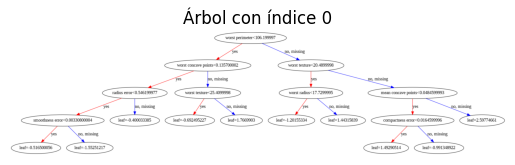

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2500x1000 with 0 Axes>

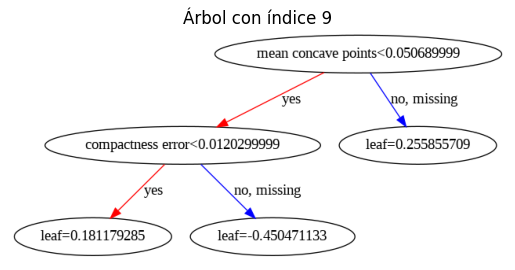

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2500x1000 with 0 Axes>

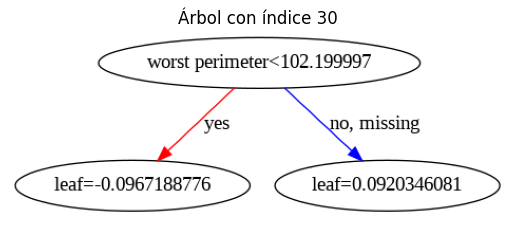

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2500x1000 with 0 Axes>

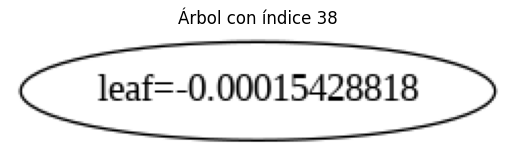

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2500x1000 with 0 Axes>

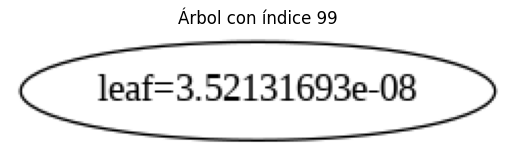

In [26]:
# 5a) Con base al modelo XGBoost generado previamente, con 100 estimadores
#     y los valores inidcados en la celda anterior, despliega los árboles
#     con índices 0, 9, 30, 38 y 99.
#
#     Puedes consultar la documentación:
#     https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.plotting
#     https://xgboosting.com/how-to-use-xgboost.plot_tree/


#########################################################################
# INICIA LA SECCIÓN PARA AGREGAR CÓDIGO.
# Agrega todas las líneas o celdas de código que consideres necesarias.


from xgboost import plot_tree
import matplotlib.pyplot as plt

# Índices de árboles solicitados
arboles = [0, 9, 30, 38, 99]

for arbol in arboles:
    plt.figure(figsize=(25,10))
    plot_tree(mi_modelo_xgb, num_trees=arbol)
    plt.title(f"Árbol con índice {arbol}")
    plt.show()


# TERMINA LA SECCIÓN PARA AGREGAR CÓDIGO.
#########################################################################

**5b) Con base a los 5 diagramas de árbol obtenidos en el inciso anterior y a la manera en que funciona el modelo XGBoost, explica el comportamiento de dichos árboles en relación a su profundidad.**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

Los árboles obtenidos tienen una profundidad relativamente baja porque XGBoost no construye un único árbol complejo, sino múltiples árboles pequeños y secuenciales. Cada árbol aprende de los errores del anterior y realiza ajustes específicos para mejorar las predicciones. Esta estrategia ayuda a evitar el sobreajuste y permite que la combinación de muchos árboles simples genere un modelo más preciso y con mejor capacidad de generalización.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

**5c) En particular, explica el grafo obtenido con tree_idx=9, con respecto a los nombres de los factores que aparecen en cada uno de sus nodos y delas clases de salida Benigno-Maligno.**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

Cada nodo representa una condicion basado en en un balor umbral de alguna coracteristica el conjunto de datos. Dependiendo de estas divisiones, el arbol dirige los casos hacia las hojas asociados a benigno o maligno y esto hace que se reduzca el error acumulado y mejora de la clasificacion final

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

**5d) ¿Cómo interpretas lo gráficos 38 y 99?**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

Son simples y solo tienen un nodo, lo que nos da una idea de que este ya no encontro divisiones suficientes para reducir el error

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

**5e) De hecho, puedes verificar que para este ejemplo los árboles obtenidos desde el índice 38 al 99, todos son de un solo nodo. ¿Qué recomendaciones o ajustes podrías proponer en el entrenamiento del modelo tomando en cuenta esta observación?**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

Ya que aparece haber alcanzado un punto donde agregar mas arboles, una recomendacion seria reducir el valor de n stimator apoerta muy poca informacion, se podria agregar early stopping poara detener el entrenamiento cuando el desempeño deje de mejorar

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

## **Ejercicio - 6**

**Incluye tus comentarios finales de esta actividad:**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

En esta actividad fue posible analizar el comportamiento del modelo XGBoost y comprender como funciona la construccion secuencial de arboles para mejorar las predicciones. Se observo que el modelo genera multiples arboles pequeños y poco profundos, donde cada uno corrige errores de los anteriores, evitando el sobreajuste y mejorando la capacidad de generalizacion. Ademas, el analisis de los ultimos arboles permitio identificar que algunos ya no aportaban mejoras, me ayuda a comprender la importancia de ajustar parametros como el numero de estimadores o utilizar tecnicas como early stopping para optimizar el entrenamiento del modelo.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

# **<<Fin de la Actividad de la Semana : modelos basados en árboles>>**